In [340]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("iris_cleaned.csv")

In [341]:
display(df.describe())
display(df)

,measurement.number,sepal.length,sepal.width,petal.length,petal.width
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,75.046980,5.843624,3.058389,3.754362,1.194631
std,43.234955,0.830851,0.435595,1.746095,0.762622
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.000000,5.100000,2.800000,1.600000,0.300000
50%,75.000000,5.800000,3.000000,4.300000,1.300000
75%,112.000000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


,measurement.number,sepal.length,sepal.width,petal.length,petal.width,variety
0,1,5.1,3.5,1.4,0.2,Setosa
1,2,4.9,3.0,1.4,0.2,Setosa
2,3,4.7,3.2,1.3,0.2,Setosa
3,4,4.6,3.1,1.5,0.2,Setosa
4,5,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...,...
144,146,6.7,3.0,5.2,2.3,Virginica
145,147,6.3,2.5,5.0,1.9,Virginica
146,148,6.5,3.0,5.2,2.0,Virginica
147,149,6.2,3.4,5.4,2.3,Virginica


### a)
This inserts a new column into the actual DataFrame df with `apply()`. Using a lambda\
function, we can loop through each row (called "i" here), thanks to the `axis=1`, as it\
applies the lambda function to the rows.\
We then access the value of row i in column `"petal.length"` and divide it by the value\
of row i in column `"petal.width"` to obtain the final value that we insert into row i\
in the new column `"petal.ratio`.

,measurement.number,sepal.length,sepal.width,petal.length,petal.width,variety,petal.ratio
0,1,5.1,3.5,1.4,0.2,Setosa,7.000000
1,2,4.9,3.0,1.4,0.2,Setosa,7.000000
2,3,4.7,3.2,1.3,0.2,Setosa,6.500000
3,4,4.6,3.1,1.5,0.2,Setosa,7.500000
4,5,5.0,3.6,1.4,0.2,Setosa,7.000000
...,...,...,...,...,...,...,...
144,146,6.7,3.0,5.2,2.3,Virginica,2.260870
145,147,6.3,2.5,5.0,1.9,Virginica,2.631579
146,148,6.5,3.0,5.2,2.0,Virginica,2.600000
147,149,6.2,3.4,5.4,2.3,Virginica,2.347826


Text(0.5, 0, 'petal.ratio')

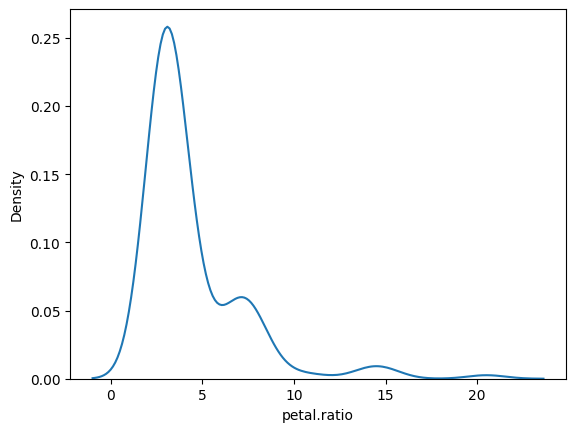

In [342]:
df["petal.ratio"] = df.apply(lambda i: i["petal.length"]/i["petal.width"], axis=1)
display(df)
sns.kdeplot(df["petal.ratio"]).set_xlabel("petal.ratio")

### b)

When using `z score normalization` we do $z\_score\_norm = \frac{x - mean}{standard deviation}$.

So each numerical column has a `mean` and a `std`, which we can use to apply `z score normalization` per column, as done below.

Just have to verify whatever that means.

np.float64(-1.8578826913704856)

np.float64(1.0014360705343693e-15)

[]

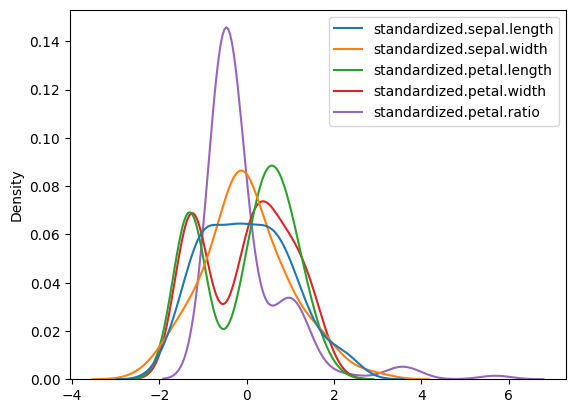

In [343]:
numerical_values = ["sepal.length", "sepal.width", "petal.length", "petal.width", "petal.ratio"]
standerdized_numerical_values = ["standardized.sepal.length", "standardized.sepal.width", "standardized.petal.length", "standardized.petal.width", "standardized.petal.ratio"]

def z_score_normalization(x, mean, standard_deviation):
    return (x-mean)/standard_deviation

st = pd.DataFrame()
for col in numerical_values:
    m = df[col].mean()
    std_dev = df[col].std()
    z = df.apply(lambda i: z_score_normalization(i[col], m, std_dev), axis=1)
    st[f"standardized.{col}"] = z

st.pivot_table(index="standardized.sepal.length", values=standerdized_numerical_values)
# display(st)
display(st["standardized.sepal.length"].min())
display(st["standardized.sepal.length"].mean())
sns.kdeplot(st).plot()

This does the z ... with the global mean and std. Makes no sense actually.

In [344]:
# numerical_values = ["sepal.length", "sepal.width", "petal.length", "petal.width", "petal.ratio"]
# standerdized_numerical_values = ["standardized.sepal.length", "standardized.sepal.width", "standardized.petal.length", "standardized.petal.width", "standardized.petal.ratio"]

# # Removes non numerical values from the table.. did this part late, that's why there is
# # still the arrays with the numerical columns in place, even though now, wouldn't need
# # them.
# df.drop("measurement.number", axis="columns", inplace=True)
# df.drop("variety", axis="columns", inplace=True)

# def z_score_normalization(x, mean, standard_deviation):
#     return (x-mean)/standard_deviation

# mean = np.mean(df.mean())
# std = np.std(df.std())
# display(mean, std)

# st = pd.DataFrame()
# for col in numerical_values:
#     z = df.apply(lambda i: z_score_normalization(i[col], mean, std), axis=1)
#     st[f"standardized.{col}"] = z

# st.pivot_table(index="standardized.sepal.length", values=standerdized_numerical_values)
# # display(st)
# display(st["standardized.sepal.length"].min())
# display(st["standardized.sepal.length"].mean())
# sns.kdeplot(st).plot()

### c)
For this section minmax, we removed the petal.ratio, as it is a ratio and posseses no unit, unlike width or height, both spactial units.

This section below performs minmax on each column with their own column's min and max value.

In [345]:
# new_standerdized_numerical_values = ["standardized.sepal.length", "standardized.sepal.width", "standardized.petal.length", "standardized.petal.width"]
# min_max_numerical_values = ["min_max.sepal.length", "min_max.sepal.width", "min_max.petal.length", "min_max.petal.width"]
# st_mm = pd.DataFrame()

# def minmax(x, x_min, x_max):
#     return (x-x_min)/(x_max-x)

# for col in new_standerdized_numerical_values:
#     x_min = st[col].min()
#     x_max = st[col].max()
#     temp = st.apply(lambda i: minmax(i[col], x_min, x_max), axis=1)
#     st_mm[f"min_max.{col}"] = temp

# # display(st_mm)
# sns.kdeplot(st_mm).plot()

This section below performs minmax on each column with the global min and max value.

,standardized.sepal.length,standardized.sepal.width,standardized.petal.length,standardized.petal.width,standardized.petal.ratio
count,1.490000e+02,1.490000e+02,1.490000e+02,1.490000e+02,1.490000e+02
mean,1.001436e-15,-4.053432e-16,-3.338120e-16,-3.814995e-16,-4.768743e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.857883e+00,-2.429753e+00,-1.577441e+00,-1.435351e+00,-8.085658e-01
25%,-8.950148e-01,-5.931864e-01,-1.233817e+00,-1.173098e+00,-5.695347e-01
50%,-5.250538e-02,-1.340447e-01,3.124901e-01,1.381669e-01,-3.924747e-01
75%,6.696455e-01,5.546678e-01,7.706553e-01,7.937995e-01,9.148945e-02
max,2.475023e+00,3.079947e+00,1.801527e+00,1.711685e+00,5.698391e+00


-2.4297531918788926

5.6983911777128275

[]

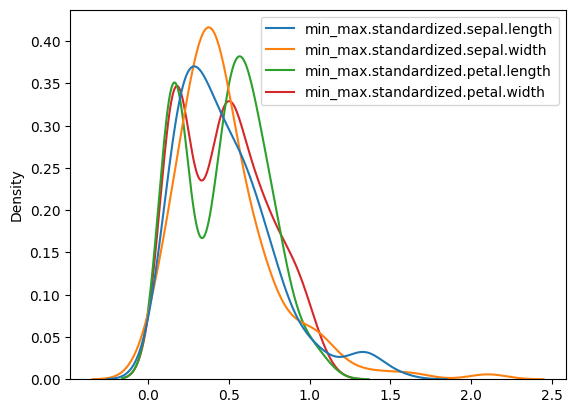

In [346]:
new_standerdized_numerical_values = ["standardized.sepal.length", "standardized.sepal.width", "standardized.petal.length", "standardized.petal.width"]
min_max_numerical_values = ["min_max.sepal.length", "min_max.sepal.width", "min_max.petal.length", "min_max.petal.width"]

global_st_mm = pd.DataFrame()

def minmax(x, x_min, x_max):
    return (x-x_min)/(x_max-x)

display(st.describe())
display(min(st.min()))
display(max(st.max()))
x_min = min(st.min())
x_max = max(st.max())

for col in new_standerdized_numerical_values:
    temp = st.apply(lambda i: minmax(i[col], x_min, x_max), axis=1)
    global_st_mm[f"min_max.{col}"] = temp

# display(st_mm)
sns.kdeplot(global_st_mm).plot()

### d)
Yes.

### e)
Yes. It actually does though. WHY ? idk.